# Limits of the group contrast (Moore et al. Batch_1, pancreatic cancer)

Everything here stays on DESeq2's own scale -- TMM-log2 residualized on each run's own RUVg W,
standardized on the batch-matched healthy controls. No normative model is used, so the
heterogeneity shown below cannot be an artefact of the normative Z.

The question is not whether the group contrast is significant, but whether the group mean it
reports describes the patients it was computed from.

In [6]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [7]:
import sys
import pandas as pd

sys.path.insert(0, '..')
from viz_style import apply_style
apply_style()
import config
from analysis.plot_group_contrast import (centering_contrast, load, outlier_decomposition,
                                          plot_direction, plot_top_degs, representativeness)

OUT = config.EDA_GROUP_CONTRAST_DIR
FIG = config.EDA_GROUP_CONTRAST_FIG_DIR
FIG.mkdir(parents=True, exist_ok=True)

D = load()
print(f"cases={int(D['is_case'].sum())} HC={int(D['is_hc'].sum())} genes={len(D['genes'])}")

cases=72 HC=69 genes=18892


## 1. The group mean does not represent its own patients

`abs_mean_over_sd` is the group mean divided by the between-patient SD on the run's own DE genes.
`sign_concordance` asks only for direction: what fraction of patients sit on the side the group
mean claims. 0.5 is a coin flip.

In [8]:
rep = representativeness(D, save_path=OUT / 'representativeness.csv')
rep.round(3)

,design,n_genes,n_case,abs_mean_over_sd_med,frac_ams_lt_05,sign_concordance_med,frac_sc_lt_05,frac_sc_lt_06
0,no_covariate,113,72,0.449,0.735,0.667,0.106,0.186
1,ruvg_k1,246,72,0.319,0.817,0.625,0.390,0.472
2,ruvg_k2,364,72,0.325,0.821,0.625,0.338,0.467
3,ruvg_k3,345,72,0.325,0.838,0.625,0.325,0.432


## 2. Centering is not a free choice

Without centering both statistics stop asking about deviation and start reporting absolute
abundance. Centering on the healthy controls is the most conservative of the three options.

In [9]:
centering_contrast(D, save_path=OUT / 'centering_contrast.csv').round(3)

,centering,abs_mean_over_sd_med,sign_concordance_med
0,none (raw TMM-log2),3.035,0.972
1,HC mean,0.325,0.625
2,HC mean and SD,0.325,0.625
3,all-sample mean,0.159,0.528


## 3. The figures

,design,median,frac_below_05,frac_below_06
0,no_covariate,0.667,0.106,0.186
1,ruvg_k1,0.625,0.390,0.472
2,ruvg_k2,0.625,0.338,0.467
3,ruvg_k3,0.625,0.325,0.432


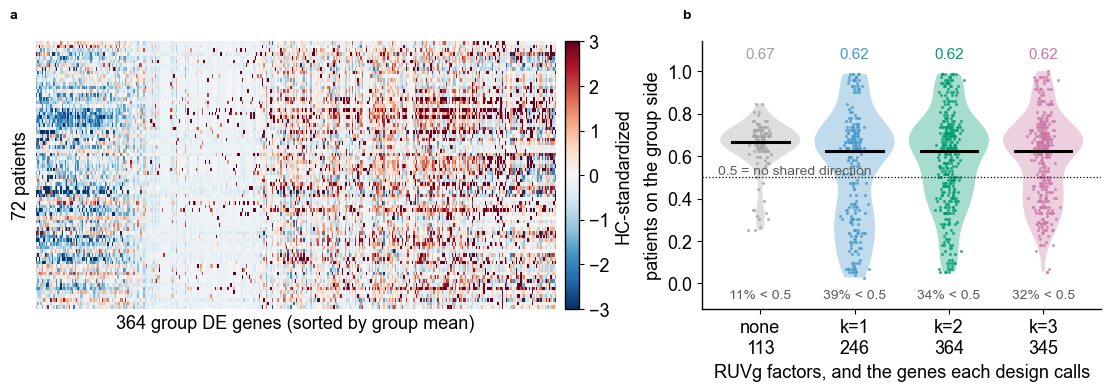

In [11]:
fig, direction_tbl = plot_direction(D, save_path=FIG / 'fig_group_direction.png')
direction_tbl.round(3)

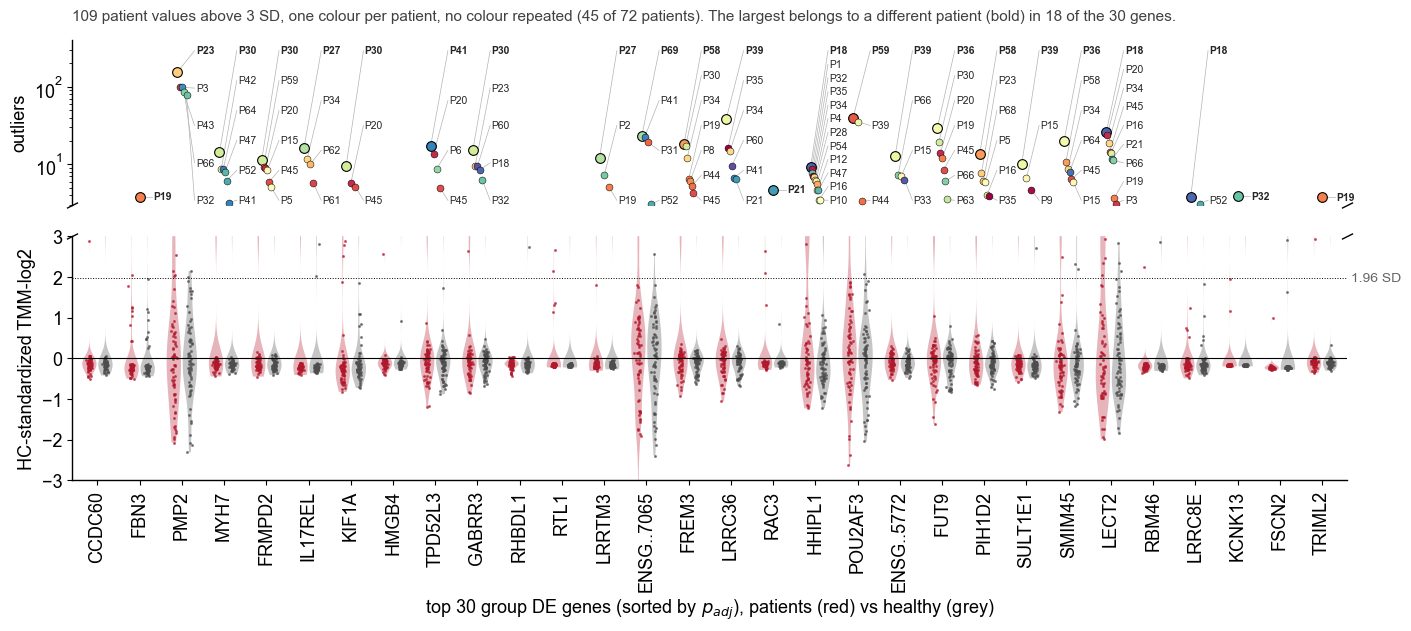

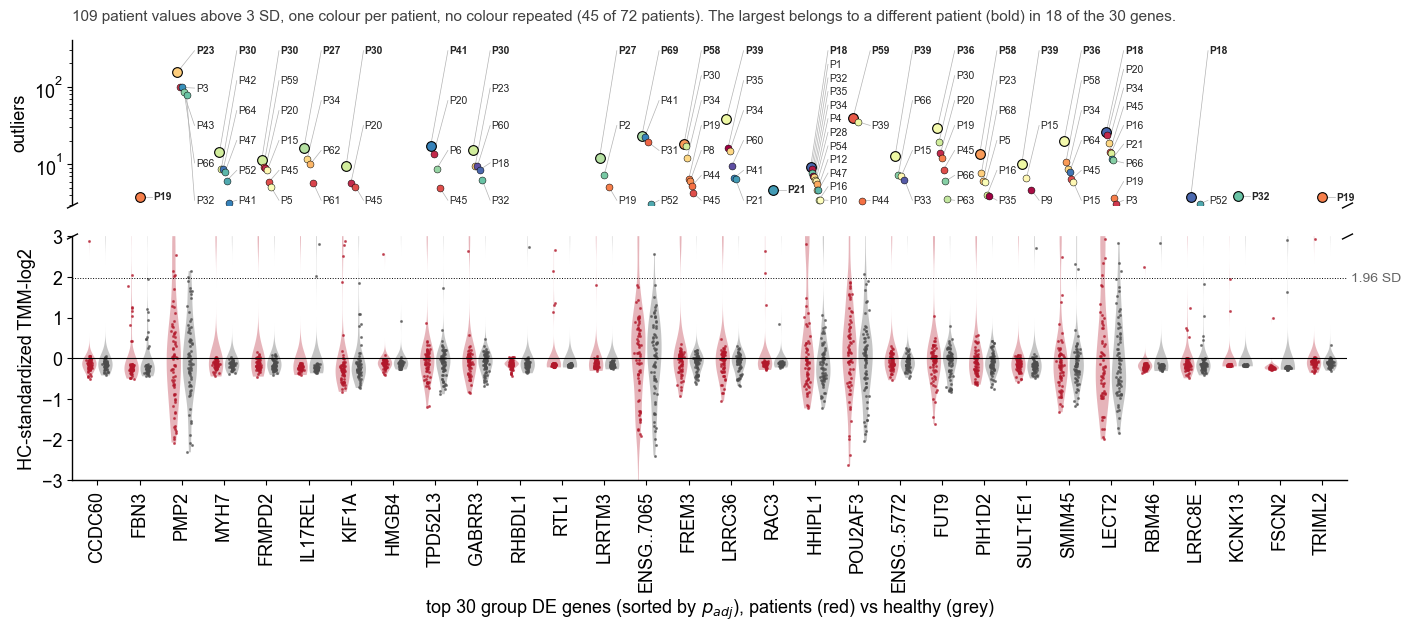

In [12]:
plot_top_degs(D, save_path=FIG / 'fig_group_top_degs_violin.png', n_show=30)

## 4. Is it a handful of outlier patients?

No. Extreme values are spread across nearly every patient and across a large share of the DE
genes, and dropping any single patient barely moves the group mean. The failure is pervasive
heterogeneity, not a few bad samples -- which is why trimming outliers would not rescue the
group contrast.

In [ ]:
outlier_decomposition(D, save_path=OUT / 'outlier_decomposition.csv').round(4)

,design,thr,n_extreme,frac_extreme,patients_with_extreme,n_patients,genes_with_extreme,n_genes,loo_mean_shift_med,loo_mean_shift_max
0,ruvg_k2,6.0,483,0.0184,67,72,148,364,0.0142,0.0343
